<a href="https://colab.research.google.com/github/gauravramola07/Gaurav_MBA_AI-DS_Python/blob/MBA_AI_DS/Time_Series_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
raw_csv_data = pd.read_csv("/content/013 IndexE8.csv")

In [4]:
df_comp = raw_csv_data.copy()

In [8]:
df_comp.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


In [9]:
df_comp.describe()

,spx,dax,ftse,nikkei
count,6269.000000,6269.000000,6269.000000,6269.000000
mean,1288.127542,6080.063363,5422.713545,14597.055700
std,487.586473,2754.361032,1145.572428,4043.122953
min,438.920000,1911.700000,2876.600000,7054.980000
25%,990.671905,4069.350000,4486.100000,10709.290000
50%,1233.420000,5773.340000,5662.430000,15028.170000
75%,1459.987747,7443.070000,6304.250000,17860.470000
max,2872.867839,13559.600000,7778.637689,24124.150000


In [10]:
df_comp.isna()

,date,spx,dax,ftse,nikkei
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
6264,False,False,False,False,False
6265,False,False,False,False,False
6266,False,False,False,False,False
6267,False,False,False,False,False


In [11]:
df_comp.isna().sum()

,0
date,0
spx,0
dax,0
ftse,0
nikkei,0


In [14]:
df_comp['spx'].isna().sum()

0

<Axes: >

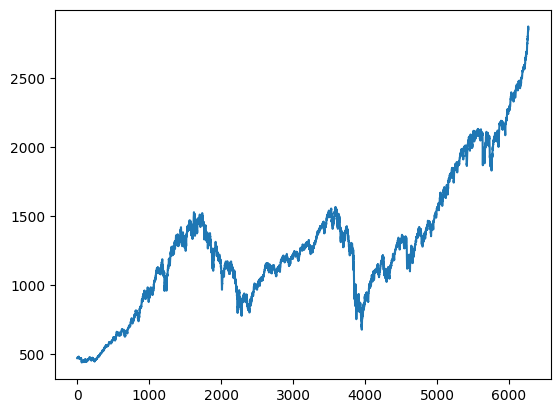

In [15]:
df_comp.spx.plot()


<Axes: title={'center': 'S&P 500 Prices'}>

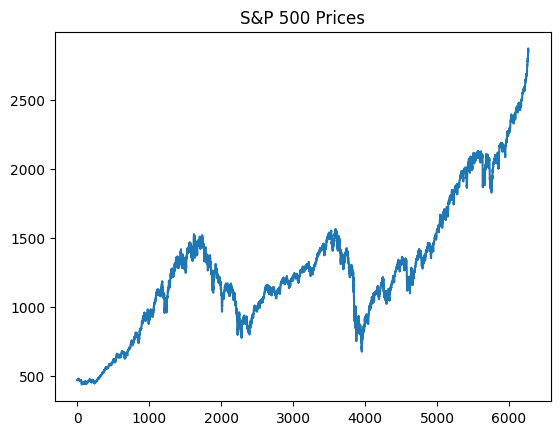

In [16]:
df_comp.spx.plot(title="S&P 500 Prices")

<Axes: title={'center': 'S&P 500 Prices'}>

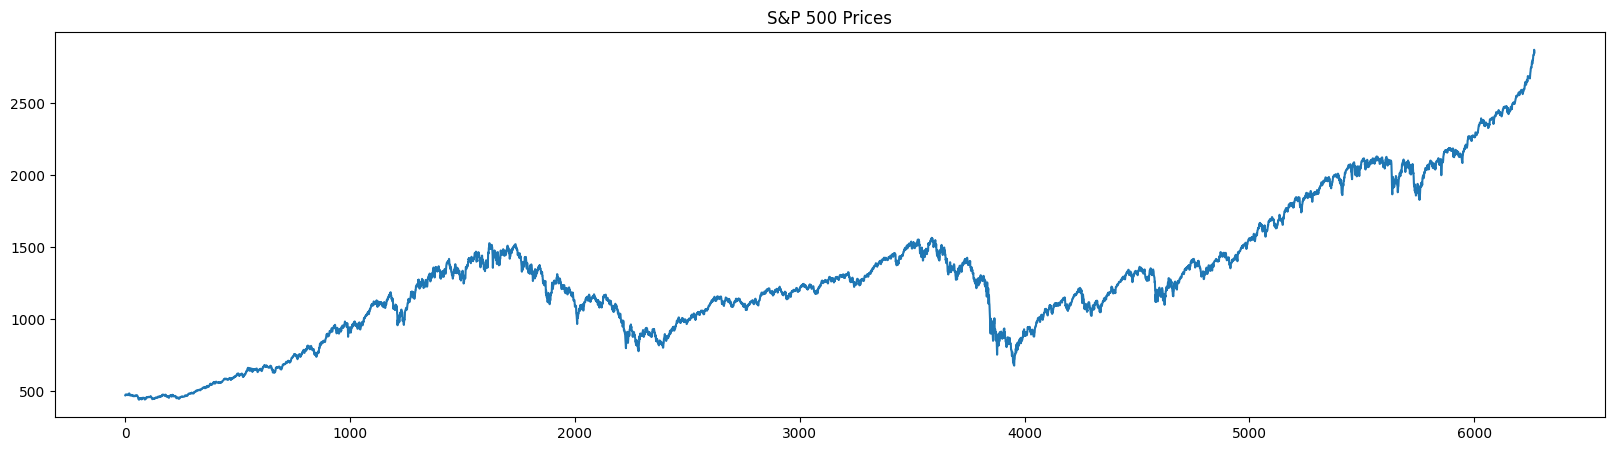

In [17]:
df_comp.spx.plot(title="S&P 500 Prices",figsize=(20,5))

Text(0.5, 1.0, 'S&P 500 and FTSE 100 Prices')

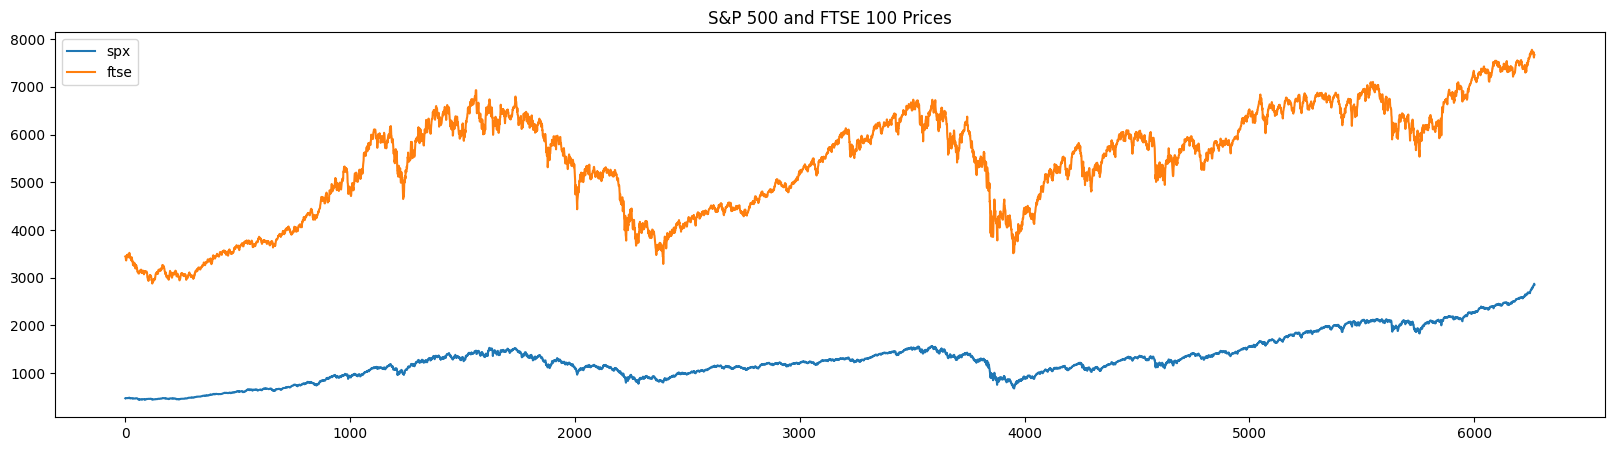

In [25]:
df_comp[['spx', 'ftse']].plot(figsize=(20, 5))
plt.title("S&P 500 and FTSE 100 Prices")


Text(0.5, 1.0, 'spx,dax,ftse and nikkei Prices')

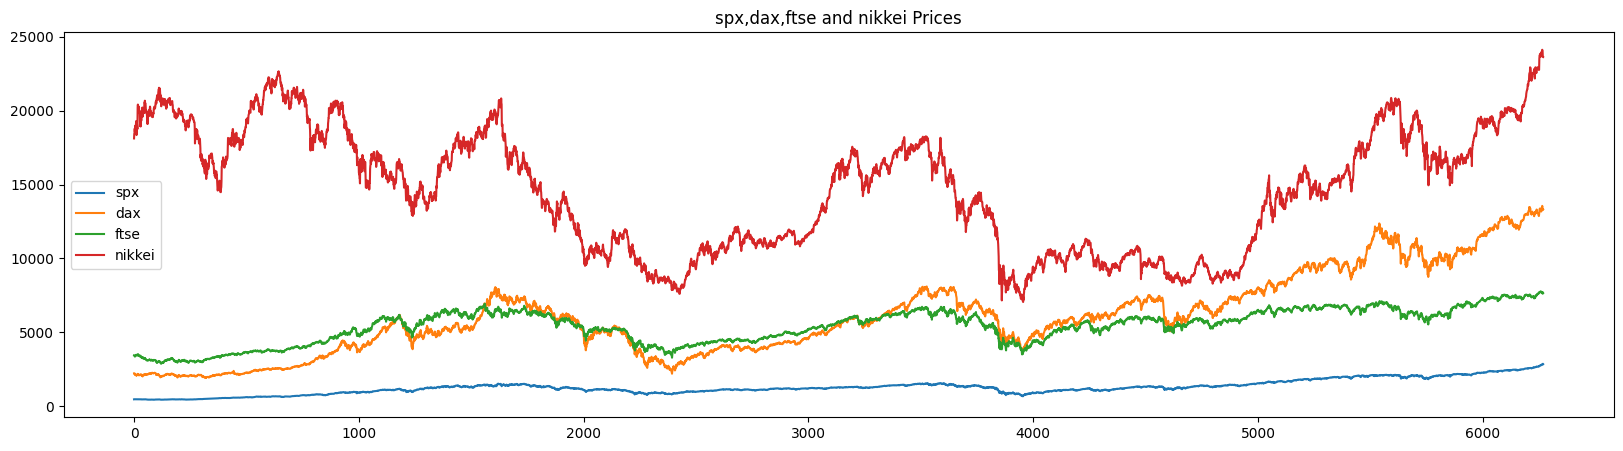

In [29]:
df_comp[['spx','dax','ftse','nikkei']].plot(figsize=(20, 5))
plt.title("spx,dax,ftse and nikkei Prices")


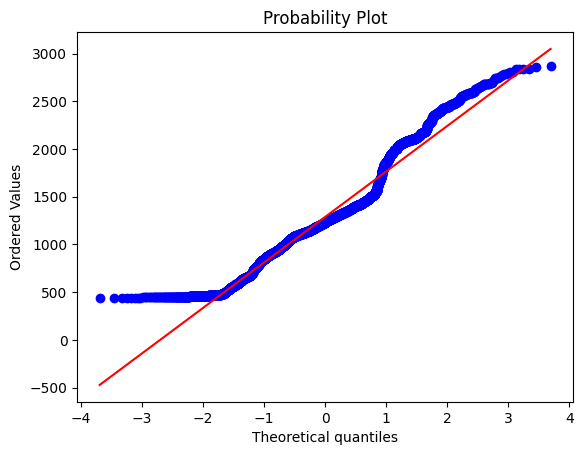

In [35]:
#QQ_PLOT
from scipy.stats import probplot

probplot(df_comp['spx'], plot=plt)
plt.show()


In [36]:
#Date Columnt date*time format

df_comp.describe()

,spx,dax,ftse,nikkei
count,6269.000000,6269.000000,6269.000000,6269.000000
mean,1288.127542,6080.063363,5422.713545,14597.055700
std,487.586473,2754.361032,1145.572428,4043.122953
min,438.920000,1911.700000,2876.600000,7054.980000
25%,990.671905,4069.350000,4486.100000,10709.290000
50%,1233.420000,5773.340000,5662.430000,15028.170000
75%,1459.987747,7443.070000,6304.250000,17860.470000
max,2872.867839,13559.600000,7778.637689,24124.150000


In [37]:
df_comp.date.describe()

,date
count,6269
unique,6269
top,07/01/1994
freq,1


In [40]:
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)

In [41]:
df_comp.head()

,date,spx,dax,ftse,nikkei
0,1994-01-07,469.90,2224.95,3445.98,18124.01
1,1994-01-10,475.27,2225.00,3440.58,18443.44
2,1994-01-11,474.13,2228.10,3413.77,18485.25
3,1994-01-12,474.17,2182.06,3372.02,18793.88
4,1994-01-13,472.47,2142.37,3360.01,18577.26


In [42]:
df_comp.date.describe()

,date
count,6269
mean,2006-01-14 19:36:59.492742144
min,1994-01-07 00:00:00
25%,2000-01-11 00:00:00
50%,2006-01-12 00:00:00
75%,2012-01-19 00:00:00
max,2018-01-29 00:00:00


In [46]:
#setting index

df_comp.set_index("date", inplace=True)

In [47]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


In [48]:
df_comp.date.describe()

AttributeError: 'DataFrame' object has no attribute 'date'

In [50]:
#setting frequency
df_comp = df_comp.asfreq('b')

In [51]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


In [52]:
df_comp.isna().sum()

,0
spx,8
dax,8
ftse,8
nikkei,8


In [53]:
df_comp.spx.fillna(value=df_comp.spx.mean(), inplace=True)

<ipython-input-53-5e6c42a0be31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_comp.spx.fillna(value=df_comp.spx.mean(), inplace=True)


In [55]:
df_comp.ftse.fillna(value=df_comp.spx.mean(), inplace=True)

<ipython-input-55-58789061906f>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_comp.ftse.fillna(value=df_comp.spx.mean(), inplace=True)


In [56]:
df_comp.nikkei.fillna(value=df_comp.spx.mean(), inplace=True)

<ipython-input-56-a80d483baec7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_comp.nikkei.fillna(value=df_comp.spx.mean(), inplace=True)


In [57]:
df_comp.isna().sum()

,0
spx,0
dax,0
ftse,0
nikkei,0


In [58]:
df_comp['market_value'] = df_comp.spx

In [59]:
del df_comp['spx'], df_comp['dax'], df_comp['ftse'], df_comp['nikkei']

In [61]:
df_comp.describe()

,market_value
count,6277.000000
mean,1288.127542
std,487.275611
min,438.920000
25%,993.055652
50%,1233.980000
75%,1459.684218
max,2872.867839


In [63]:
#splitting the data set

size = int(len(df_comp)*0.8)

In [64]:
df = df_comp.iloc[:size]

In [65]:
df_test = df_comp.iloc[size:]

In [66]:
df.tail()

,market_value
date,
2013-04-01,1562.173837
2013-04-02,1570.252238
2013-04-03,1553.686978
2013-04-04,1559.979316
2013-04-05,1553.278930


In [67]:
df_test.head()

,market_value
date,
2013-04-08,1563.071269
2013-04-09,1568.607909
2013-04-10,1587.731827
2013-04-11,1593.369863
2013-04-12,1588.854623
